In [1]:
vocabulary = [
    "king", "queen", "man", "woman", "boy", "girl",
    "father", "mother", "brother", "sister", "child",
    "family", "person", "people", "friend", "love",
    "life", "world", "day", "night",
    
    "run", "walk", "eat", "drink", "read", "write",
    "learn", "teach", "build", "create", "develop",
    "analyze", "predict", "train", "test", "improve",
    
    "big", "small", "fast", "slow", "smart", "strong",
    "happy", "sad", "good", "bad", "new", "old",
    "early", "late",
    
    "data", "text", "word", "sentence", "document",
    "token", "embedding", "vector", "matrix", "model",
    "training", "prediction", "classification",
    "language", "context", "feature", "algorithm",
    "dataset"
]

In [3]:
import gensim
from sklearn.manifold import TSNE

In [4]:
import gensim.downloader as api

In [5]:
glove_model = api.load( "glove-wiki-gigaword-300")

[==================================================] 100.0% 376.1/376.1MB downloaded


In [6]:
glove_model.most_similar("king")

[('queen', 0.6336469054222107),
 ('prince', 0.6196622848510742),
 ('monarch', 0.5899620652198792),
 ('kingdom', 0.5791266560554504),
 ('throne', 0.5606487989425659),
 ('ii', 0.5562329292297363),
 ('iii', 0.5503199100494385),
 ('crown', 0.5224862694740295),
 ('reign', 0.5217353701591492),
 ('kings', 0.5066401958465576)]

In [7]:
glove_model.most_similar(positive=["king", "women"], negative=["man"], topn=1)

[('queen', 0.484937459230423)]

In [9]:
words = []
word_vec = []

for word in vocabulary:
    words.append(word)
    word_vec.append(glove_model[word])

In [10]:
words

['king',
 'queen',
 'man',
 'woman',
 'boy',
 'girl',
 'father',
 'mother',
 'brother',
 'sister',
 'child',
 'family',
 'person',
 'people',
 'friend',
 'love',
 'life',
 'world',
 'day',
 'night',
 'run',
 'walk',
 'eat',
 'drink',
 'read',
 'write',
 'learn',
 'teach',
 'build',
 'create',
 'develop',
 'analyze',
 'predict',
 'train',
 'test',
 'improve',
 'big',
 'small',
 'fast',
 'slow',
 'smart',
 'strong',
 'happy',
 'sad',
 'good',
 'bad',
 'new',
 'old',
 'early',
 'late',
 'data',
 'text',
 'word',
 'sentence',
 'document',
 'token',
 'embedding',
 'vector',
 'matrix',
 'model',
 'training',
 'prediction',
 'classification',
 'language',
 'context',
 'feature',
 'algorithm',
 'dataset']

In [13]:
word_vec[0].shape

(300,)

In [14]:
len(words)

68

In [15]:
dicts = zip(words, word_vec)

In [16]:
import pandas as pd

In [17]:
data = pd.DataFrame.from_dict(dicts)

In [18]:
data

,0,1
0,king,"[0.0033901, -0.34614, 0.28144, 0.48382, 0.5946..."
1,queen,"[-0.22184, 0.064884, -0.086365, 0.51279, 0.325..."
2,man,"[-0.29784, -0.13255, -0.14505, -0.22752, -0.02..."
3,woman,"[-0.51821, -0.13809, -0.41185, -0.13133, 0.003..."
4,boy,"[-0.29973, -0.10202, -0.41355, -0.23211, -0.22..."
...,...,...
63,language,"[-0.67832, -0.28658, -0.28904, 0.15099, -0.467..."
64,context,"[-0.186, -0.40557, -0.1271, -0.0071974, 0.4070..."
65,feature,"[-0.11993, 0.42657, -0.11238, -0.43258, 0.0660..."
66,algorithm,"[-0.95834, 0.8063, 0.95844, -0.18573, -0.46141..."


In [23]:
dim_model = TSNE(n_components=2, perplexity = 3, init='pca', random_state=42)


In [28]:
import numpy as np

word_vec_array = np.array(word_vec)
fit_model = dim_model.fit_transform(word_vec_array)


In [29]:
fit_model

array([[ 34.504417  , -39.083145  ],
       [ 35.820538  , -39.573593  ],
       [ 13.892354  , -26.575092  ],
       [ 14.081607  , -28.798138  ],
       [ 14.867653  , -33.53079   ],
       [ 14.823395  , -32.10281   ],
       [ 25.487251  , -38.43267   ],
       [ 21.450262  , -38.41247   ],
       [ 26.953856  , -37.95829   ],
       [ 21.154099  , -40.059948  ],
       [ 18.761059  , -36.51077   ],
       [ 25.58598   , -41.449463  ],
       [ 11.94296   , -25.184584  ],
       [  9.977775  , -23.66988   ],
       [ 26.124622  , -35.59271   ],
       [ 11.242703  ,  -5.9230614 ],
       [ 12.348074  ,  -8.854002  ],
       [ -4.7631173 , -16.656195  ],
       [ -7.150329  , -14.458238  ],
       [ -6.9089675 , -12.976839  ],
       [ -2.177747  , -12.142627  ],
       [ -0.5234606 , -11.393956  ],
       [ 25.01309   ,  19.097246  ],
       [ 25.81816   ,  18.037014  ],
       [-18.116407  ,  15.633934  ],
       [-16.68944   ,  15.397669  ],
       [ -9.218424  ,  17.189564  ],
 

In [30]:
import matplotlib.pyplot as plt

In [31]:
x = []
y = []

for i in fit_model:
    x.append(i[0])
    y.append(i[1]) 

In [32]:
x

[np.float32(34.504417),
 np.float32(35.820538),
 np.float32(13.892354),
 np.float32(14.081607),
 np.float32(14.867653),
 np.float32(14.823395),
 np.float32(25.487251),
 np.float32(21.450262),
 np.float32(26.953856),
 np.float32(21.154099),
 np.float32(18.761059),
 np.float32(25.58598),
 np.float32(11.94296),
 np.float32(9.977775),
 np.float32(26.124622),
 np.float32(11.242703),
 np.float32(12.348074),
 np.float32(-4.7631173),
 np.float32(-7.150329),
 np.float32(-6.9089675),
 np.float32(-2.177747),
 np.float32(-0.5234606),
 np.float32(25.01309),
 np.float32(25.81816),
 np.float32(-18.116407),
 np.float32(-16.68944),
 np.float32(-9.218424),
 np.float32(-8.295277),
 np.float32(5.9341607),
 np.float32(6.139065),
 np.float32(4.254512),
 np.float32(-11.879085),
 np.float32(-10.491509),
 np.float32(-8.704338),
 np.float32(-10.689652),
 np.float32(2.0343373),
 np.float32(12.59919),
 np.float32(14.462882),
 np.float32(25.894526),
 np.float32(27.0869),
 np.float32(5.6963587),
 np.float32(8.33391

In [34]:
y

[np.float32(-39.083145),
 np.float32(-39.573593),
 np.float32(-26.575092),
 np.float32(-28.798138),
 np.float32(-33.53079),
 np.float32(-32.10281),
 np.float32(-38.43267),
 np.float32(-38.41247),
 np.float32(-37.95829),
 np.float32(-40.059948),
 np.float32(-36.51077),
 np.float32(-41.449463),
 np.float32(-25.184584),
 np.float32(-23.66988),
 np.float32(-35.59271),
 np.float32(-5.9230614),
 np.float32(-8.854002),
 np.float32(-16.656195),
 np.float32(-14.458238),
 np.float32(-12.976839),
 np.float32(-12.142627),
 np.float32(-11.393956),
 np.float32(19.097246),
 np.float32(18.037014),
 np.float32(15.633934),
 np.float32(15.397669),
 np.float32(17.189564),
 np.float32(16.145903),
 np.float32(16.679504),
 np.float32(14.833166),
 np.float32(16.736921),
 np.float32(31.009985),
 np.float32(32.789494),
 np.float32(-17.741844),
 np.float32(-13.979625),
 np.float32(17.322184),
 np.float32(6.3018346),
 np.float32(6.3397684),
 np.float32(-0.2797828),
 np.float32(0.32774565),
 np.float32(-0.32605463

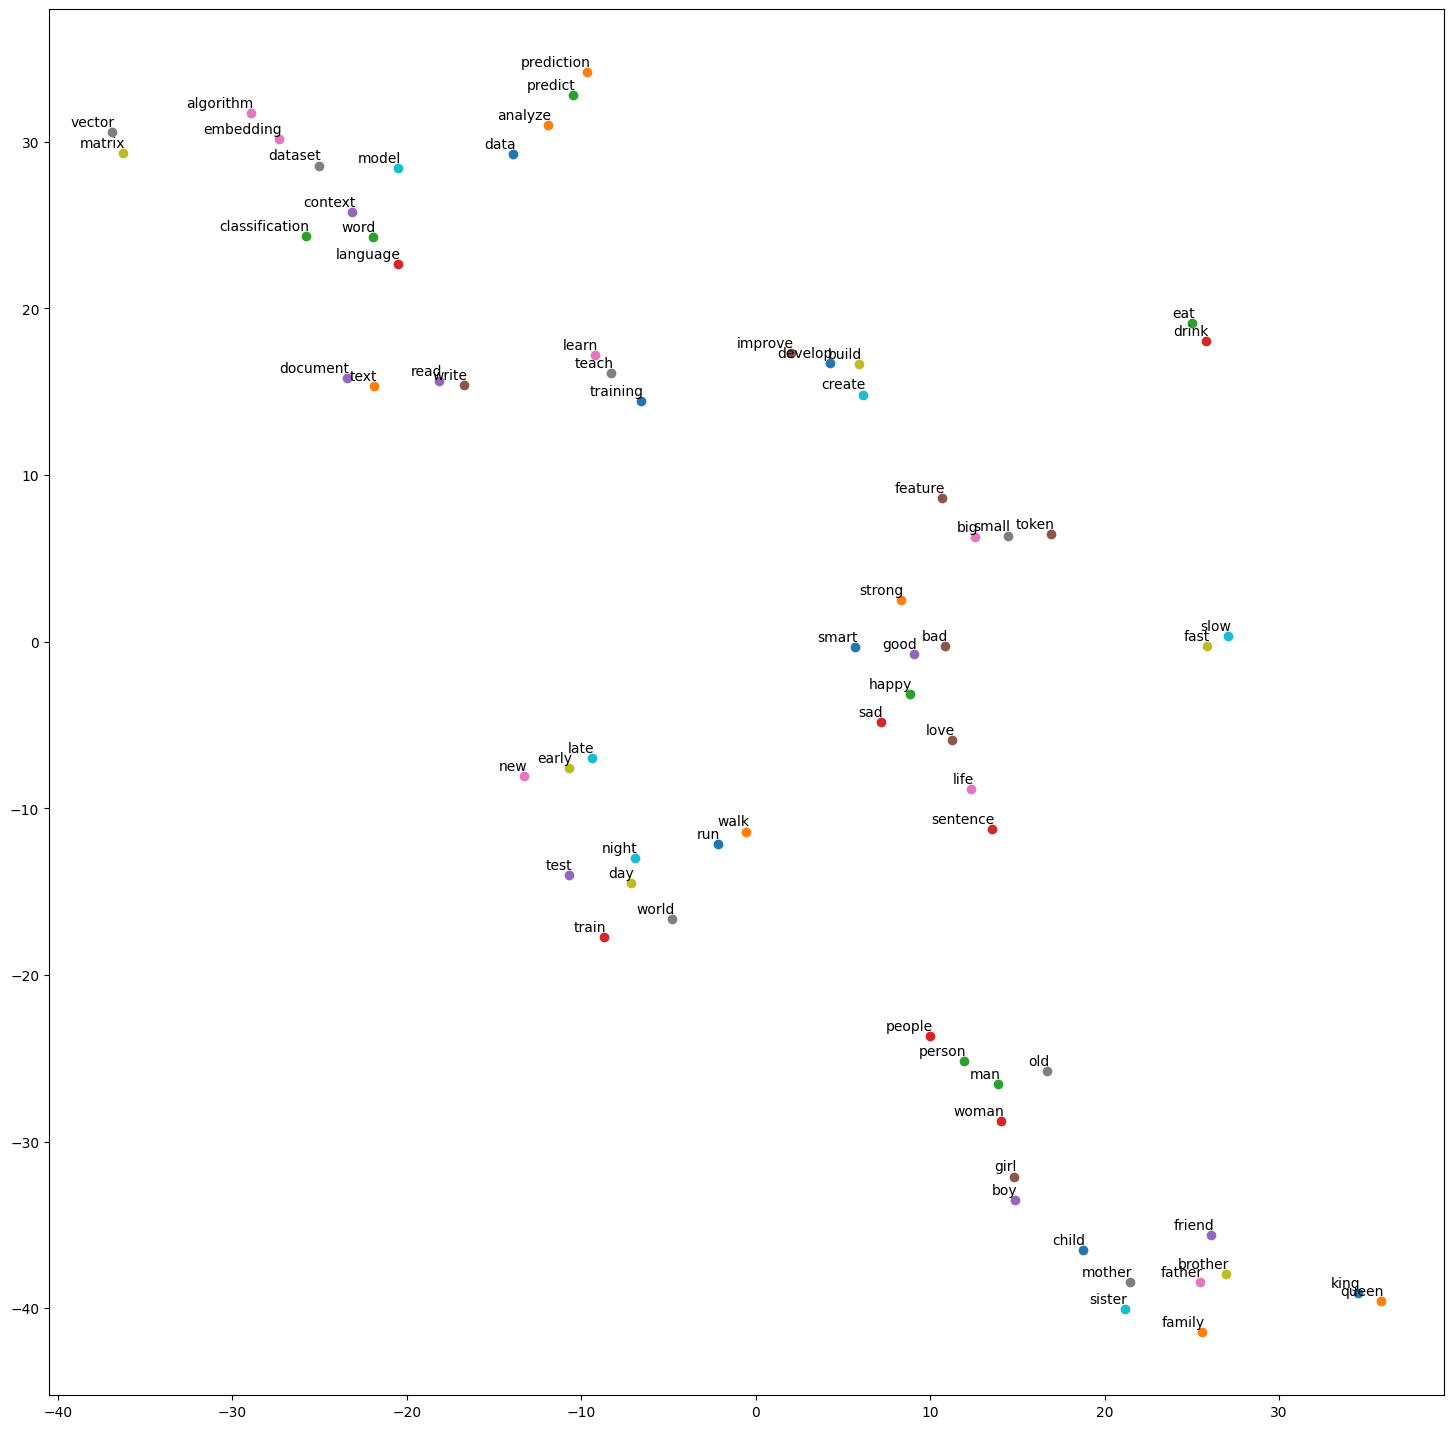

In [43]:

plt.figure(figsize=(18,18))

for i in range(len(x)):
    plt.scatter(x[i],y[i])
    plt.annotate(words[i], xy=(x[i],y[i]),
                 xytext=(2, 2),
                 textcoords='offset points',
                 ha='right',
                 va='bottom'
                )